In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2472s 14us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


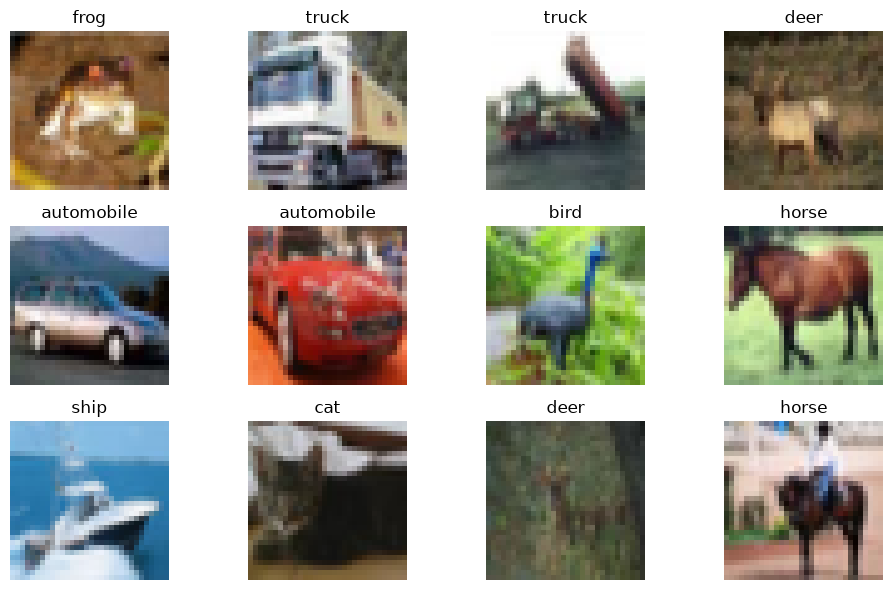

In [5]:
import matplotlib.pyplot as plt

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()



In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(X_train.shape)
print(X_val.shape)

(45000, 32, 32, 3)
(5000, 32, 32, 3)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.summary()

c:\Users\PC-LAB1\Desktop\shok\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6403 - loss: 1.0296 - val_accuracy: 0.6880 - val_loss: 0.8881
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6500 - loss: 1.0117 - val_accuracy: 0.6548 - val_loss: 0.9943
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6516 - loss: 1.0078 - val_accuracy: 0.6506 - val_loss: 1.0100
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6571 - loss: 0.9928 - val_accuracy: 0.6840 - val_loss: 0.9285
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6578 - loss: 0.9802 - val_accuracy: 0.6934 - val_loss: 0.9050
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6656 - loss: 0.9679 - val_accuracy: 0.6520 - val_loss: 1.0270
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6672 - loss: 0.9640 - val_accuracy: 0.6760 - val_loss: 0.9696
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6695 - loss: 0.9542 - va

In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7051 - loss: 0.8728
Test accuracy: 0.7050999999046326


In [20]:
predictions = model.predict(X_test)

y_pred = predictions.argmax(axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


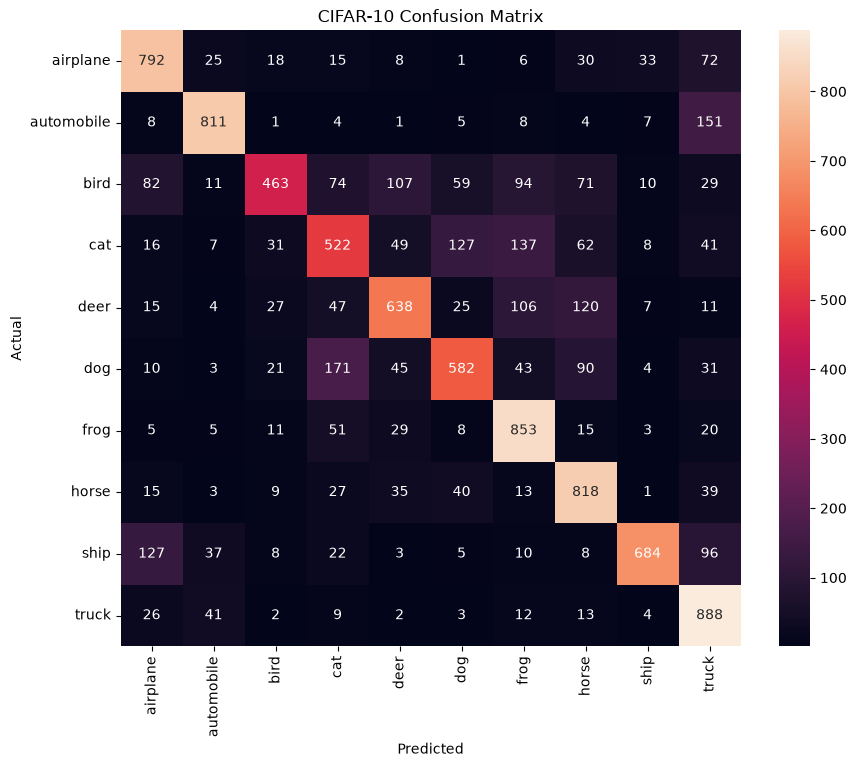

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

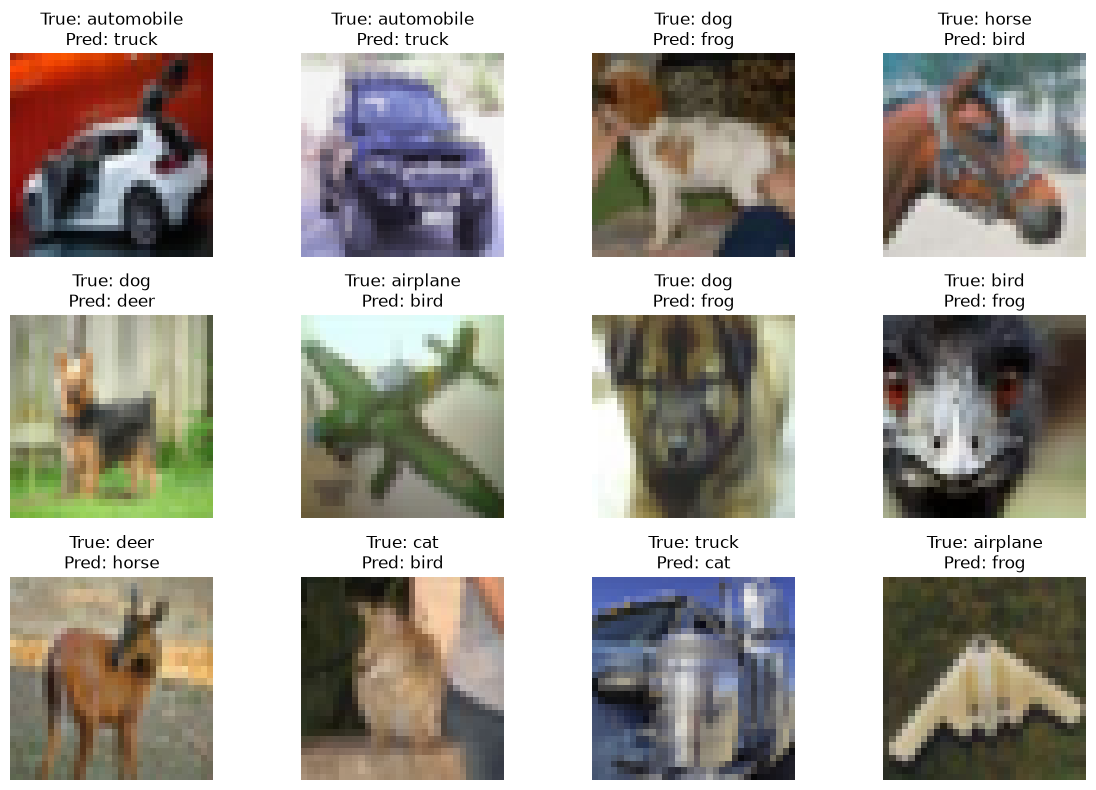

In [13]:
wrong = []

for i in range(len(y_test)):
    if y_true[i] != y_pred[i]:
        wrong.append(i)

plt.figure(figsize=(12, 8))

for j, i in enumerate(wrong[:12]):
    plt.subplot(3, 4, j + 1)

    plt.imshow(X_test[i])

    plt.title(
        f"True: {class_names[y_true[i]]}\n"
        f"Pred: {class_names[y_pred[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
#step 9

from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

model = Sequential([
    data_augmentation,

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history_aug = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.3116 - loss: 1.8467 - val_accuracy: 0.4326 - val_loss: 1.5351
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4432 - loss: 1.5371 - val_accuracy: 0.4744 - val_loss: 1.4668
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4899 - loss: 1.4231 - val_accuracy: 0.5268 - val_loss: 1.3020
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5187 - loss: 1.3497 - val_accuracy: 0.5364 - val_loss: 1.3200
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5452 - loss: 1.2875 - val_accuracy: 0.6004 - val_loss: 1.1224
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5644 - loss: 1.2432 - val_accuracy: 0.6050 - val_loss: 1.1272
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5746 - loss: 1.2125 - val_accuracy: 0.6164 - val_loss: 1.0859
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5843 - loss: 1.1824 - va

In [16]:
test_loss_aug, test_accuracy_aug = model.evaluate(
    X_test,
    y_test
)

print("Test accuracy:", test_accuracy_aug)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6442 - loss: 1.0866
Test accuracy: 0.6442000269889832


In [22]:
#saving model

model.save("cifar10_cnn.keras")